# Downloading dataset

In [2]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


# Importing libraries

In [3]:
import os
import numpy as np
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import seaborn as sns
from PIL import Image, ImageEnhance

# Loading and shuffling data

In [4]:
train_dir = f'{path}/Training'
test_dir =  f'{path}/Testing'

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    #print(label)
    for image in os.listdir(os.path.join(train_dir, label)):
      train_paths.append(os.path.join(train_dir, label, image))
      train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)
#train_paths
#train_labels

In [5]:
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
      test_paths.append(os.path.join(test_dir, label, image))
      test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Data Visualization

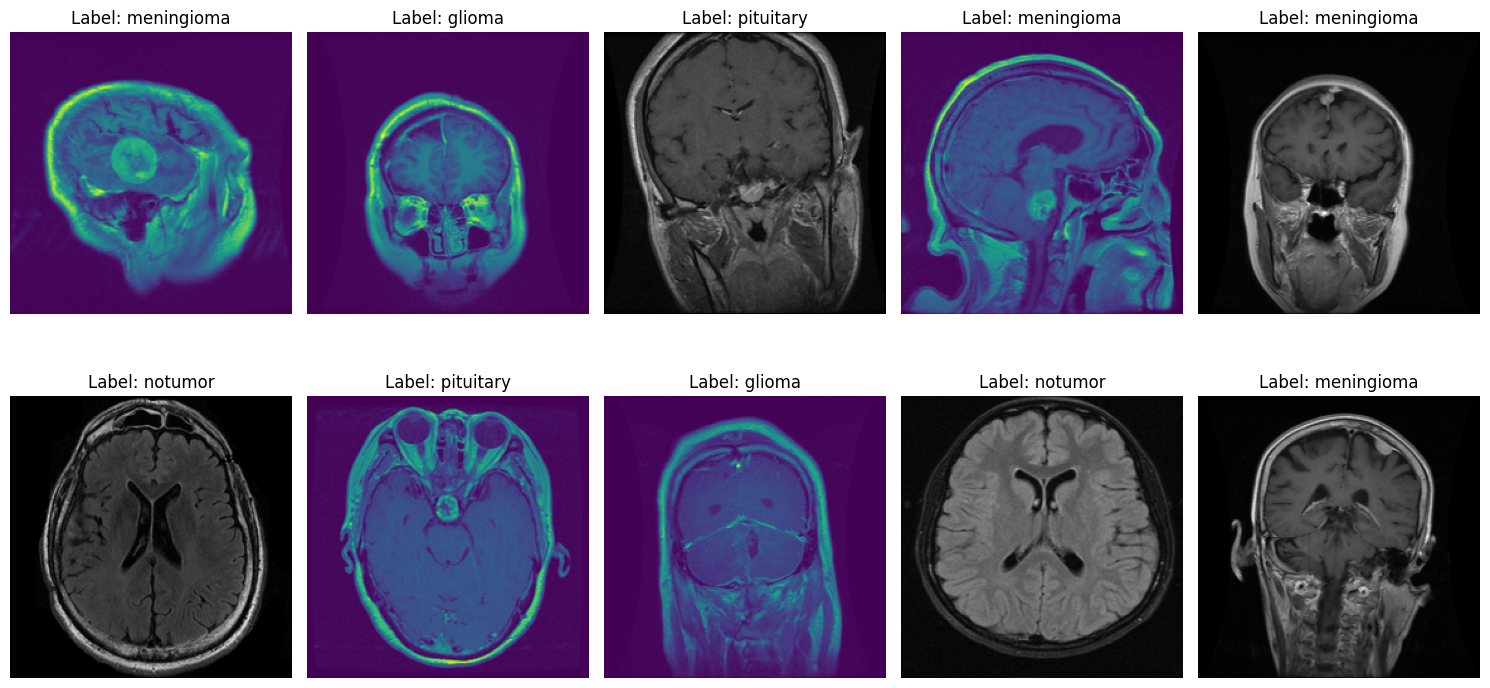

In [6]:
random_indices = random.sample(range(len(train_paths)), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=12)
plt.tight_layout()
plt.show()

# Image Preprocessing

In [7]:
#image augmentation
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image

#loading imagees
def open_images(paths):
  images = []
  for path in paths:
    image = load_img(path, target_size=(image_size, image_size))
    image = augment_image(image)
    images.append(image)
  return np.array(images)

#encoding labels
def encode_labels(labels):
  unique_labels = sorted(os.listdir(train_dir))
  encoded = [unique_labels.index(label) for label in labels]
  return np.array(encoded)

#data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
   for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i+batch_size]
            batch_labels = encode_labels(batch_labels)
            yield batch_images, batch_labels

# Model Architecture

We are using the VGG16 model for transfer learning (only for the knowledge) to give us more accurate results

In [8]:
image_size = 128
base_model = VGG16(input_shape=(image_size, image_size, 3), include_top=False, weights='imagenet')
for layer in base_model.layers:
    layer.trainable = False
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(image_size, image_size, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(.3))
model.add(Dense(128, activation="relu") )
model.add(Dropout(.2))
model.add(Dense(4, activation="softmax"))
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 5
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),epochs=epochs, steps_per_epoch=steps,)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 50s 146ms/step - loss: 0.6677 - sparse_categorical_accuracy: 0.7305
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - loss: 0.2325 - sparse_categorical_accuracy: 0.9147
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - loss: 0.1493 - sparse_categorical_accuracy: 0.9437
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 0.1131 - sparse_categorical_accuracy: 0.9574
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 0.0860 - sparse_categorical_accuracy: 0.9664


# Evaluation Results

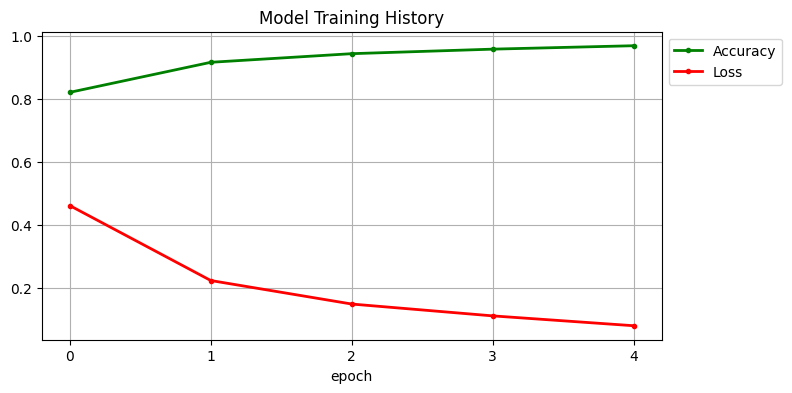

In [9]:
#let's plot
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2)
plt.plot(history.history['loss'],'.r-',linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [10]:
test_images = open_images(test_paths)
test_labels_encoded = encode_labels(test_labels)
test_predictions = model.predict(test_images)
#Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       300
           1       0.86      0.99      0.92       306
           2       1.00      0.99      0.99       405
           3       1.00      0.97      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.95      0.95      1311
weighted avg       0.96      0.96      0.96      1311



Confusion Matrix:
[[259  40   1   0]
 [  3 303   0   0]
 [  2   2 401   0]
 [  1   8   1 290]]


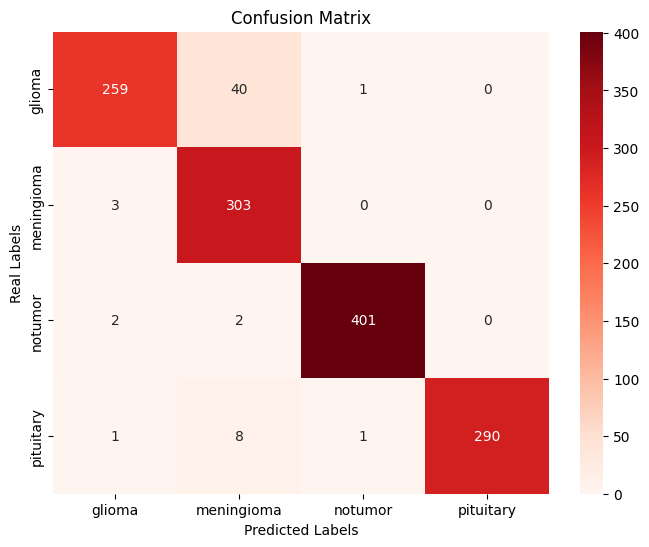

In [11]:
#Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(8, 6))
sorted_labels = sorted(os.listdir(train_dir))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=sorted_labels, yticklabels=sorted_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Real Labels")
plt.show()

# Save and Load Model

In [12]:
model.save('model.h5')

In [13]:
from tensorflow.keras.models import load_model
model = load_model('model.h5')

In [14]:
from keras.preprocessing.image import load_img, img_to_array

class_labels = sorted(os.listdir(train_dir))

def detect_and_display(img_path, model, image_size=128):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()
    except Exception as e:
        print("Error processing the image:", str(e))

/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0080.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


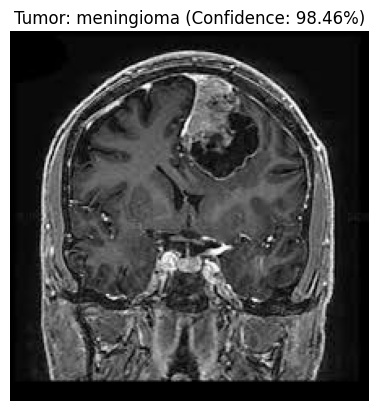

/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_0264.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


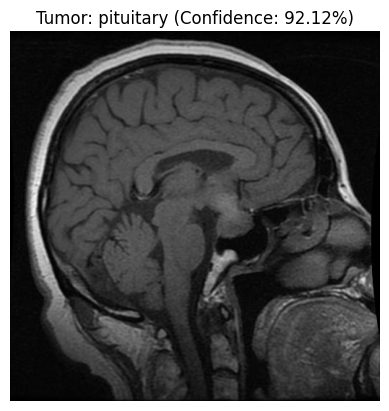

/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0169.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


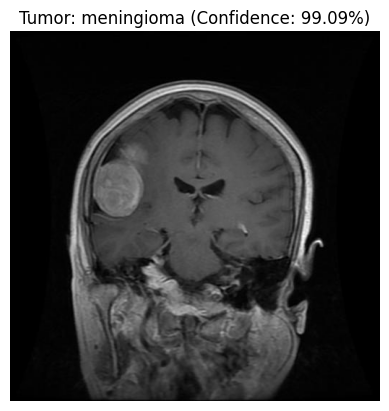

/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_0157.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


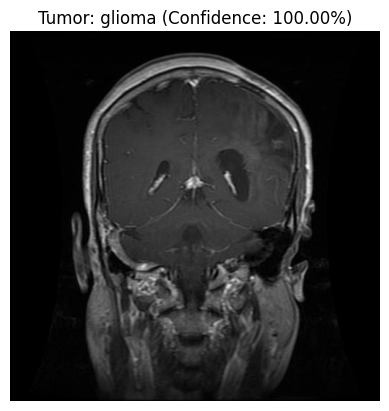

/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_0087.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


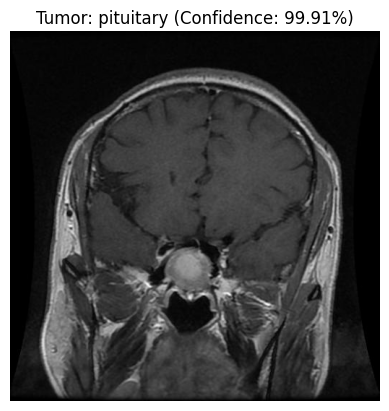

In [15]:
import random
for _ in range(5):
    img = random.choice(test_paths)
    print(img)
    detect_and_display(img, model)

In [16]:
from google.colab import files
uploaded = files.upload()

Saving brain.jpg to brain.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


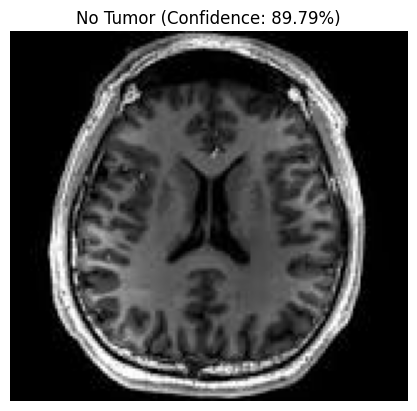

In [17]:
from PIL import Image
for filename in uploaded.keys():
    detect_and_display(filename, model)